# Imports e Configuração

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

TECNICA_ATUAL = "UnderSampling" 
PASTA_DADOS = os.path.join("..", "PreProcessing", TECNICA_ATUAL)

NOME_X_TRAIN = "X_train_under.csv"
NOME_Y_TRAIN = "y_train_under.csv"
NOME_X_TEST  = "X_test_scaled.csv"
NOME_Y_TEST  = "y_test.csv"

print(f"📘 Iniciando Treinamento XGBoost")
print(f"📂 Buscando dados no caminho relativo: {PASTA_DADOS}")

Treinamento ENSEMBLE (Soft Voting) - Dados: Undersampling


# Carregamento de dados

In [ ]:
path_X_train = os.path.join(PASTA_DADOS, NOME_X_TRAIN)
path_y_train = os.path.join(PASTA_DADOS, NOME_Y_TRAIN)
path_X_test  = os.path.join(PASTA_DADOS, NOME_X_TEST)
path_y_test  = os.path.join(PASTA_DADOS, NOME_Y_TEST)

arquivos_necessarios = [path_X_train, path_y_train, path_X_test, path_y_test]
arquivos_faltando = [arq for arq in arquivos_necessarios if not os.path.exists(arq)]

if arquivos_faltando:
    print("ERRO: Arquivos não encontrados no caminho especificado:")
    for arq in arquivos_faltando:
        print(f"   -> {arq}")
else:
    try:
        X_train = pd.read_csv(path_X_train)
        y_train = pd.read_csv(path_y_train).values.ravel()
        
        X_test = pd.read_csv(path_X_test)
        y_test = pd.read_csv(path_y_test).values.ravel()
        
        print("✅ Dados carregados com sucesso!")
        print(f"Amostras de Treino: {X_train.shape[0]}")
        print(f"Amostras de Teste:  {X_test.shape[0]}")

    except Exception as e:
        print(f"Erro inesperado ao ler os arquivos:\n{e}")

✅ Dados de Undersampling carregados!


# Treinamento

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# O XGBoost requer que as classes comecem do zero (0, 1, 2), o que já é o seu caso.
grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), param_grid, refit=True, cv=3, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"Melhores parâmetros encontrados: {grid.best_params_}")
modelo_xgb = grid.best_estimator_
y_pred = modelo_xgb.predict(X_test)

Treinamento Concluído!


# Avaliação

--- Relatório de Classificação ---
              precision    recall  f1-score   support

Saudável (0)       0.87      0.83      0.85       138
 Benigno (1)       0.77      0.46      0.58       142
  Câncer (2)       0.12      0.69      0.20        13

    accuracy                           0.64       293
   macro avg       0.59      0.66      0.54       293
weighted avg       0.79      0.64      0.69       293



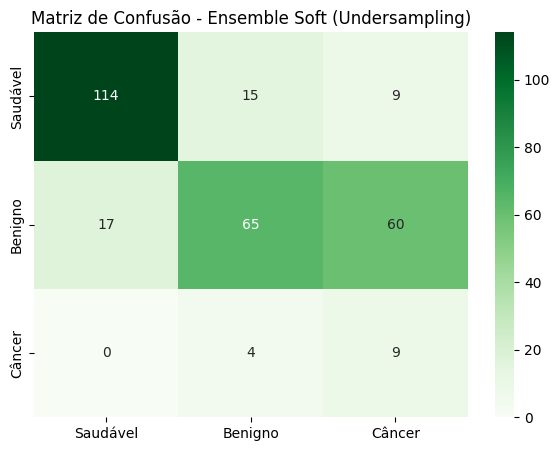

['..\\PreProcessing\\Undersampling\\modelo_ensemble_undersampling_soft.pkl']

In [ ]:
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Benigno (1)', 'Câncer (2)']))